# 强化学习——学习笔记

《强化学习导论》（Reinforcement Learning An Introduction by Richard Sutton and Andrew Barto）是强化学习领域的奠基性著作，系统阐述了该领域的核心概念、算法及应用体系。这本教材是萨顿和巴托合著的经典教材，系统阐释了强化学习的核心概念与算法。全书通过三大板块展开：从马尔可夫决策过程的基础理论，到动态规划、蒙特卡洛等核心方法，再到函数逼近、神经网络融合等前沿进展。该书以通俗语言解析复杂理论，被公认为AI领域的必读著作，适合具备概率统计基础的读者通过实践深入研习。

# 十臂测试平台
什么是十臂测试平台（10-armed Testbed）？
这是一个在强化学习中非常经典和重要的概念性工具，主要用于测试、比较和可视化不同决策算法的性能。
想象你走进一个赌场，面前有10台老虎机。每台老虎机的赢钱概率和奖金分布都不一样，但你不知道具体哪台好哪台坏。你的目标是通过有限次数的拉杆，尽可能获得最多的总奖金。

这就是强化学习中的一个核心困境：**“探索-利用”的权衡**。
*   **利用**：选择你**目前认为**能给最多奖励的那台机器。
*   **探索**：尝试你**目前不太了解**的机器，以收集更多信息，可能发现奖励更高的机器。

“十臂测试平台”就是将上述比喻具体化和数字化，以便进行实验。

它通常包含以下要素：

1.  **10个动作**：你有10个“拉杆”动作可选（动作$a=1,...,10,$）。
2.  **随机奖励**：每个动作 $a$ 都对应一个固定的、但对你隐藏的奖励概率分布$q_*(a)$。这里设定这个分布为正态分布（均值$(q_*(a)$，方差1）。$q_*(a)$ 是每个动作的“真实价值”，在实验开始时被**随机生成**（例如，从一个均值为0，方差为1的正态分布中采样），如下图所示。
3.  **交互过程**：在每一步$t$，你选择一个动作$A_t$（比如，拉动第5个拉杆），环境会从这个动作对应的奖励分布中**采样**一个奖励 $R_t$ 给你。
4.  **算法的目标**：你运行的算法（如ε-贪婪）需要根据历史交互数据 $(A_1, R_1, A_2, R_2, ...)$ 来学习并做出决策，以最大化累计奖励。


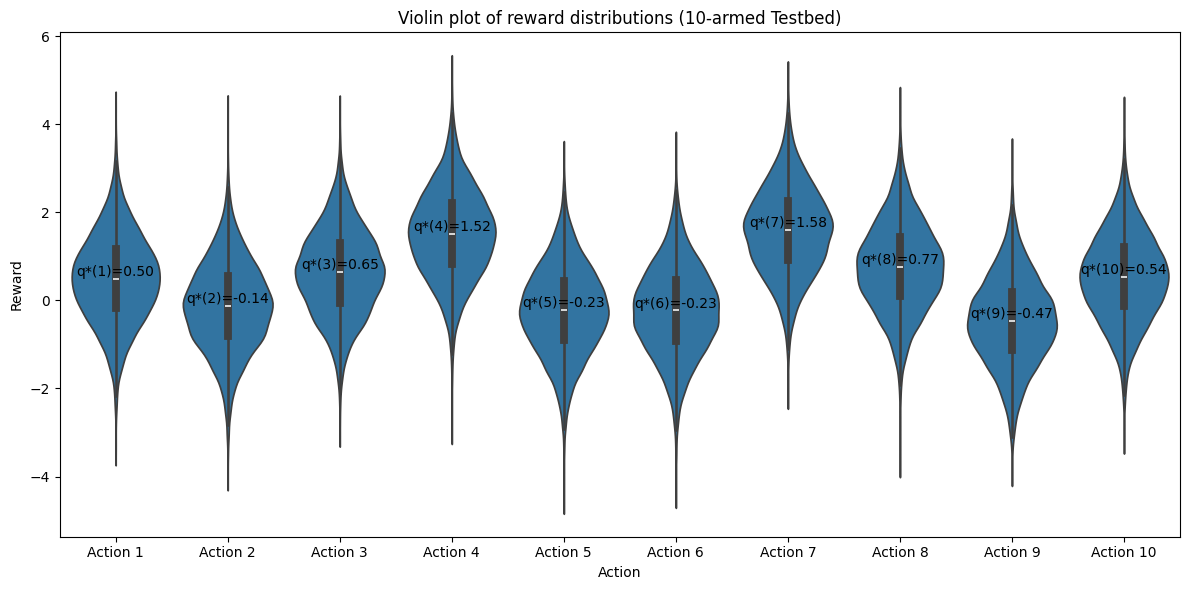

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.font_manager as fm

# 生成10个动作的真实价值 q*(a)，从均值0，方差1的正态分布中采样
np.random.seed(42)  # 设置随机种子以便重现
means = np.random.normal(0, 1, 10)

# 为每个动作生成样本数据（例如，每个动作10000个样本）
n_samples = 10000
data = []
for i, mean in enumerate(means):
    samples = np.random.normal(mean, 1, n_samples)
    for sample in samples:
        data.append({'action': f'Action {i+1}', 'reward': sample})

# 创建DataFrame
df = pd.DataFrame(data)

# 创建图形
plt.figure(figsize=(12, 6))

# 绘制小提琴图
sns.violinplot(x='action', y='reward', data=df)

# 在每个violin上方标注均值 q*(a)
for i, mean in enumerate(means):
    # 计算该动作的样本最大值
    action_data = df[df['action'] == f'Action {i+1}']['reward']
    # 在平均值上方标注均值
    plt.text(i, action_data.mean(), f'q*({i+1})={mean:.2f}', ha='center', va='bottom')

# Add title and labels
plt.title('Violin plot of reward distributions (10-armed Testbed)')
plt.xlabel('Action')
plt.ylabel('Reward')
plt.tight_layout()

## $\varepsilon$-贪婪算法
**$\varepsilon$-贪婪算法**是一个在强化学习和多臂赌博机问题中非常经典且重要的算法，用于平衡**探索** 和**利用** 这一对核心矛盾。

---

### 核心问题：探索与利用的权衡

想象一下你走进一个你有过几次经验的赌场，里面有10台老虎机（也叫“多臂赌博机”）。

- **利用**：你会倾向于玩那台在过去给你带来最多收益的老虎机。因为你**利用**了已有的知识，希望获得最大化的即时回报。
- **探索**：但你可能也会想：“万一另一台老虎机其实更好，只是我还没发现呢？” 于是你花一些钱去尝试其他老虎机，这就是**探索**。

如果只利用不探索，你可能会陷入局部最优，错过真正回报最高的选择。如果只探索不利用，你就无法最大化你的累计收益，因为你总是在“交学费”尝试新东西。

**$\varepsilon$-贪婪算法**就是为了优雅地解决这个问题而诞生的。

---

### 算法思想

$\varepsilon$-贪婪算法的思想非常简单直接：

1.  设定一个小的概率值 $\varepsilon$ (例如 0.1，即10%)。这个值控制了探索的强度。
2.  在每次需要选择行动时，生成一个0到1之间的随机数：
    - **以 $1-\varepsilon$ 的概率（大概率）**：选择**当前认为最好**的行动（即“贪婪”行动）。这是**利用**。
    - **以 $\varepsilon$ 的概率（小概率）**：**随机**选择一个行动（包括当前认为最好的那个）。这是**探索**。

这里的 $\varepsilon$ 就像一个“探索开关”，$\varepsilon$ 越大，探索就越频繁。

---

### 算法流程

我们以一个有10个臂的老虎机问题为例：

1.  **初始化**：
    - 为每个臂 $a$ 初始化价值估计 $q(a)$，例如设为0。
    - 初始化每个臂被选择的次数 $N(a) = 0$。
    - 设定探索概率 $\varepsilon$ (0 < $\varepsilon$ < 1)。

2.  **循环** (对于每一步 $t=1, 2, 3, ...$)：
    a. **选择行动**：
       - 生成一个随机数 $p \sim Uniform(0,1)$。
       - 如果 $p < \varepsilon$：
         - **探索**：从所有臂中**随机**选择一个臂 $A_t$。
       - 否则：
         - **利用**：选择当前价值估计最高的臂 $A_t = \arg\max_a Q(a)$ (如果多个臂价值相同，则随机选一个)。

    b. **执行行动**：拉动选择的臂 $A_t$，获得收益 $R_t$。

    c. **更新价值估计**：
       - 更新该臂被选择的次数：$N(A_t) \leftarrow N(A_t) + 1$。
       - 更新该臂的价值估计（采用增量更新的方式）：
         $Q(A_t) \leftarrow Q(A_t) + \frac{1}{N(A_t)} [R_t - Q(A_t)]$
         这个更新公式的意思是：新的估计 = 旧的估计 + 学习率 × (新回报 - 旧的估计)。这里的学习率是 $1/N(A_t)$。

---

### 算法的优缺点

**优点**：
- **简单易懂**：原理和实现都非常简单。
- **易于调试**：行为可预测，探索频率是固定的。
- **通常很有效**：在很多问题上都能取得不错的效果。

**缺点**：
- **探索是随机的、低效的**：在探索时，它会以同等概率去探索所有非最优的行动，即使某个行动已经明确很差了。它不会“聪明地”去探索更有潜力的行动。
- **参数 $\varepsilon$ 是固定的**：在实验初期，我们需要大量探索；而在后期，当价值估计已经很准确时，我们可能希望减少探索。固定的 $\varepsilon$ 无法适应这个需求。

---

### 改进与变体

为了解决上述缺点，研究者提出了很多改进方法：

1.  **随时间衰减的 $\varepsilon$**：
    让 $\varepsilon$ 随着时间步数 $t$ 逐渐减小，例如 $\varepsilon_t = 1/t$ 或 $\varepsilon_t = 0.99^t$。这样在初期鼓励探索，后期鼓励利用。

2.  **上置信界算法**：
    一种更“聪明”的探索策略，在选择时会考虑价值估计的不确定性。它会优先探索那些要么价值估计很高、要么不确定性很高的行动。公式为：$A_t = \arg\max_a [Q(a) + c \sqrt{\frac{\ln t}{N(a)}}]$，其中第二项就是不确定性度量。

3.  **汤普森采样**：
    一种基于贝叶斯思想的算法，为每个臂维护一个奖励分布，然后根据这个分布采样来做出选择。它以一种概率化的方式自然地平衡了探索和利用。

### 总结

$\varepsilon$-贪婪算法是解决探索-利用困境的一个**基线方法**和**强大基准**。它的核心在于以一个固定的、小的概率 $\varepsilon$ 进行随机探索，而以 $1-\varepsilon$ 的概率进行贪婪利用。虽然它有其局限性，但其简单性和有效性使其成为入门强化学习和解决多臂赌博机问题的首选算法。

### 一个典型的实验结果

在《强化学习导论》这本教材中，你会看到类似下图的描述：

> 我们运行一个2000步的实验，重复1000次取平均。
> *   **贪婪算法（ε=0）**：初期增长快，但很快达到一个较低的平均奖励水平，因为它陷入了局部最优。
> *   **ε-贪婪算法（ε=0.01）**：初期比贪婪算法慢，但最终表现更好，因为它有少量探索。
> *   **ε-贪婪算法（ε=0.1）**：探索更多，学习更慢，但最终找到了更好的策略，平均奖励最高。

**10-armed Testbed（十臂测试平台）是一个标准化的模拟环境，它抽象并简化了强化学习中的核心挑战——“探索-利用”困境。通过在这个可控的平台上测试算法，研究人员可以直观地比较不同算法的性能，理解探索的重要性，并为解决更复杂的现实世界问题打下基础。** 它是学习强化学习入门时不可或缺的一个概念。

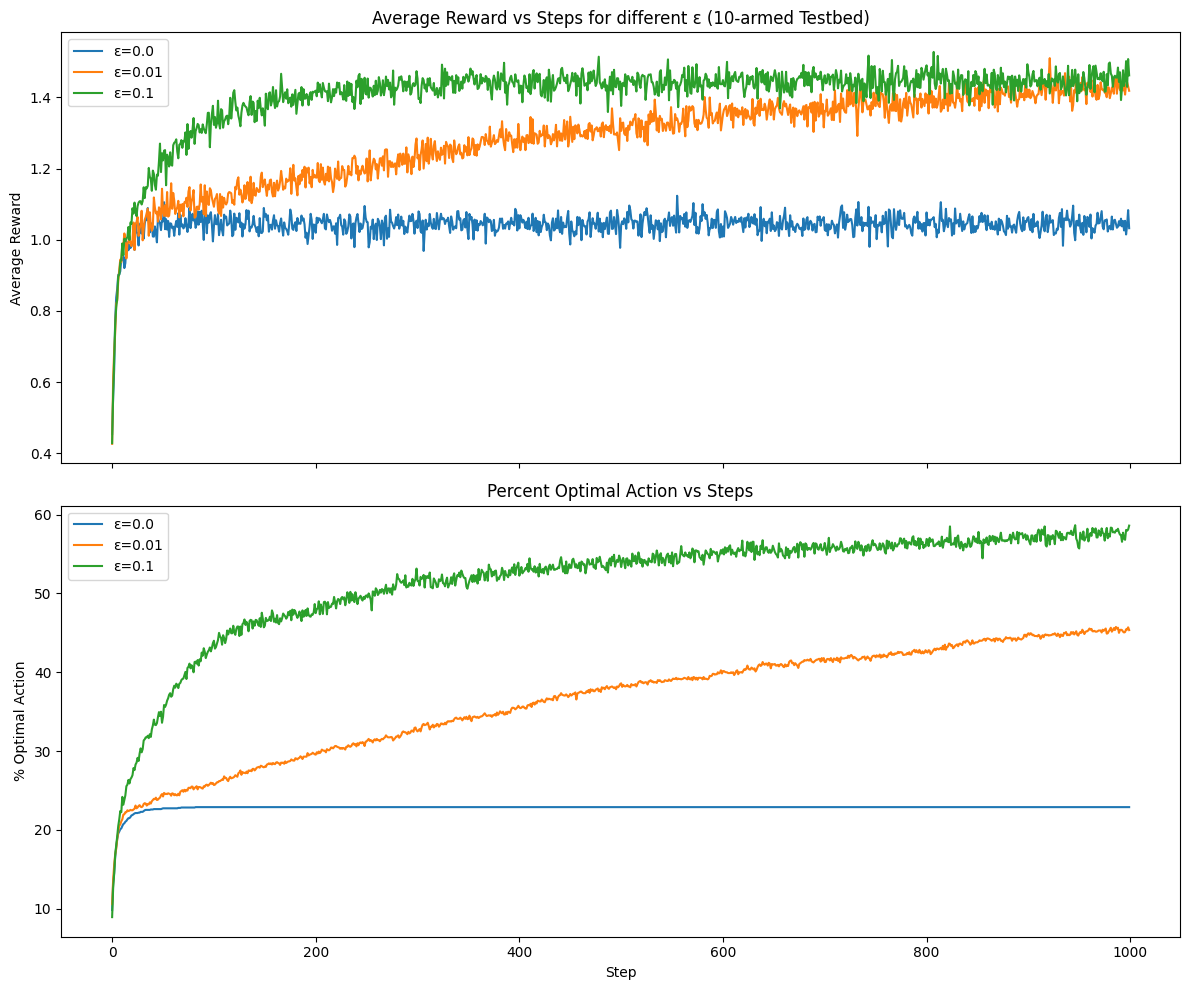

In [3]:
# ε-贪婪在10臂测试平台上的模拟与绘图
# 依赖于之前单元格已定义的变量：means, np, plt, sns

n_arms = len(means)          # 应为10
steps = 1000                 # 每次实验步数
runs = 2000                  # 重复实验次数（取平均）
epsilons = [0.0, 0.01, 0.1]  # 要比较的ε值

optimal_arm = int(np.argmax(means))

# 用于存放每个ε在每一步的平均回报和选择最优动作的比例
avg_rewards = {eps: np.zeros(steps) for eps in epsilons}
optimal_action_rates = {eps: np.zeros(steps) for eps in epsilons}

for eps in epsilons:
    rewards_all = np.zeros((runs, steps))
    optimal_chosen = np.zeros((runs, steps))
    for run in range(runs):
        Q = np.zeros(n_arms)    # 价值估计
        N = np.zeros(n_arms)    # 每臂被选次数
        for t in range(steps):
            if np.random.rand() < eps:
                # 探索：随机选择一个臂
                action = np.random.randint(n_arms)
            else:
                # 利用：选择当前估计最优（若并列则随机选择其一）
                best = np.flatnonzero(Q == Q.max())
                if best.size > 1:
                    action = np.random.choice(best)
                else:
                    action = int(best[0])
            # 从真实分布采样奖励（均值为means[action], 方差1）
            reward = np.random.normal(means[action], 1.0)
            # 增量更新
            N[action] += 1
            Q[action] += (reward - Q[action]) / N[action]

            rewards_all[run, t] = reward
            optimal_chosen[run, t] = 1 if action == optimal_arm else 0

    # 对所有重复实验取平均
    avg_rewards[eps] = rewards_all.mean(axis=0)
    optimal_action_rates[eps] = optimal_chosen.mean(axis=0) * 100.0  # 转为百分比

# 绘图：两个子图，上：平均回报；下：选择最优动作的百分比
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

colors = {0.0: 'tab:blue', 0.01: 'tab:orange', 0.1: 'tab:green'}
for eps in epsilons:
    axes[0].plot(avg_rewards[eps], label=f'ε={eps}', color=colors[eps])
axes[0].set_ylabel('Average Reward')
axes[0].set_title('Average Reward vs Steps for different ε (10-armed Testbed)')
axes[0].legend()

for eps in epsilons:
    axes[1].plot(optimal_action_rates[eps], label=f'ε={eps}', color=colors[eps])
axes[1].set_xlabel('Step')
axes[1].set_ylabel('% Optimal Action')
axes[1].set_title('Percent Optimal Action vs Steps')
axes[1].legend()

plt.tight_layout()


#### 长期表现
对于长期运行，我们发现$\varepsilon=0.01$的表现比其他两个参数要好，运行的结果如下图所示。
经过计算发现$\varepsilon=0.01$的最终受益比$\varepsilon=0.1$大概多0.1。

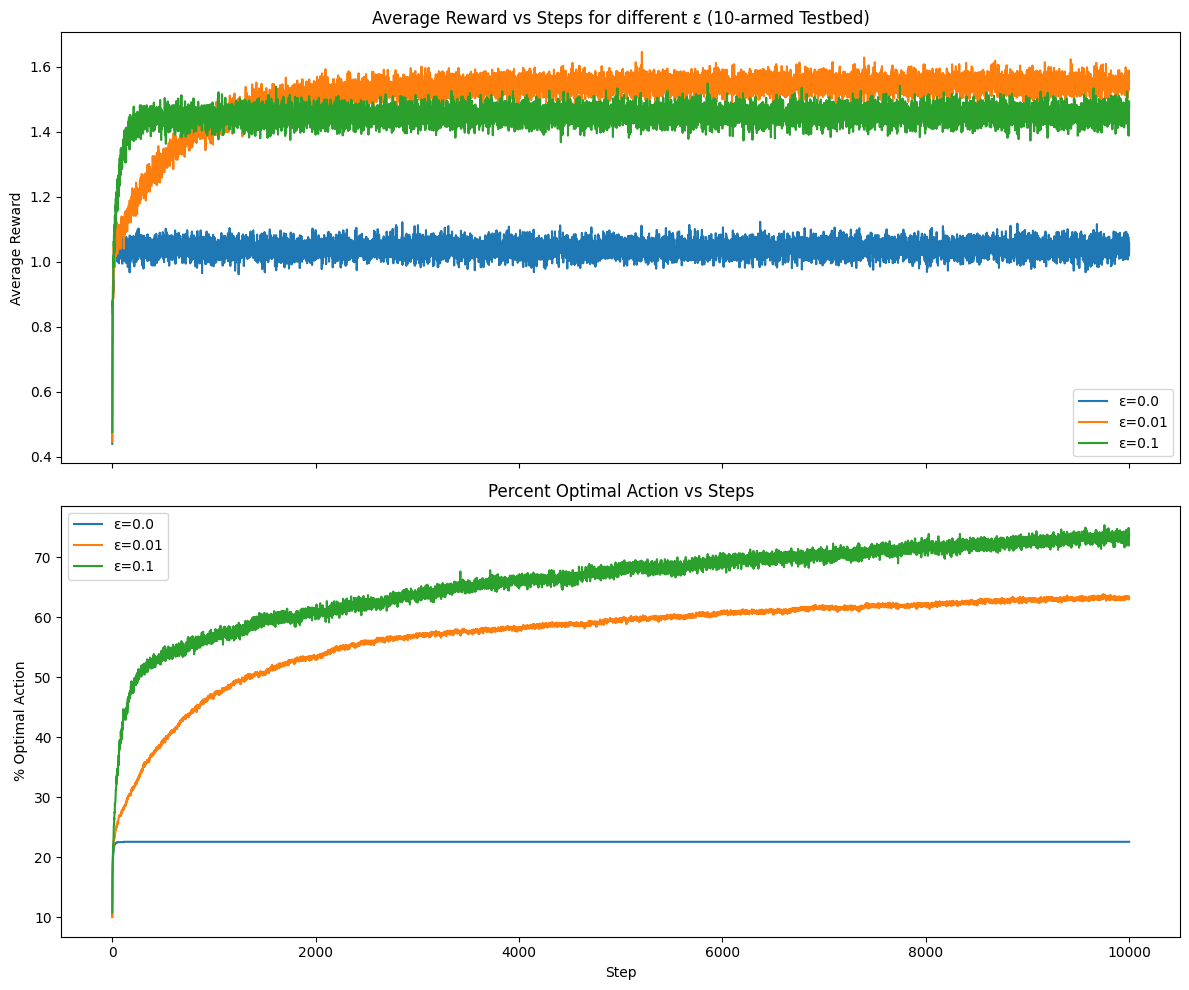

In [4]:
# ε-贪婪在10臂测试平台上的模拟与绘图
# 依赖于之前单元格已定义的变量：means, np, plt, sns

n_arms = len(means)          # 应为10
steps = 10000                 # 每次实验步数
runs = 2000                  # 重复实验次数（取平均）
epsilons = [0.0, 0.01, 0.1]  # 要比较的ε值

optimal_arm = int(np.argmax(means))

# 用于存放每个ε在每一步的平均回报和选择最优动作的比例
avg_rewards = {eps: np.zeros(steps) for eps in epsilons}
optimal_action_rates = {eps: np.zeros(steps) for eps in epsilons}

for eps in epsilons:
    rewards_all = np.zeros((runs, steps))
    optimal_chosen = np.zeros((runs, steps))
    for run in range(runs):
        Q = np.zeros(n_arms)    # 价值估计
        N = np.zeros(n_arms)    # 每臂被选次数
        for t in range(steps):
            if np.random.rand() < eps:
                # 探索：随机选择一个臂
                action = np.random.randint(n_arms)
            else:
                # 利用：选择当前估计最优（若并列则随机选择其一）
                best = np.flatnonzero(Q == Q.max())
                if best.size > 1:
                    action = np.random.choice(best)
                else:
                    action = int(best[0])
            # 从真实分布采样奖励（均值为means[action], 方差1）
            reward = np.random.normal(means[action], 1.0)
            # 增量更新
            N[action] += 1
            Q[action] += (reward - Q[action]) / N[action]

            rewards_all[run, t] = reward
            optimal_chosen[run, t] = 1 if action == optimal_arm else 0

    # 对所有重复实验取平均
    avg_rewards[eps] = rewards_all.mean(axis=0)
    optimal_action_rates[eps] = optimal_chosen.mean(axis=0) * 100.0  # 转为百分比

# 绘图：两个子图，上：平均回报；下：选择最优动作的百分比
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

colors = {0.0: 'tab:blue', 0.01: 'tab:orange', 0.1: 'tab:green'}
for eps in epsilons:
    axes[0].plot(avg_rewards[eps], label=f'ε={eps}', color=colors[eps])
axes[0].set_ylabel('Average Reward')
axes[0].set_title('Average Reward vs Steps for different ε (10-armed Testbed)')
axes[0].legend()

for eps in epsilons:
    axes[1].plot(optimal_action_rates[eps], label=f'ε={eps}', color=colors[eps])
axes[1].set_xlabel('Step')
axes[1].set_ylabel('% Optimal Action')
axes[1].set_title('Percent Optimal Action vs Steps')
axes[1].legend()

plt.tight_layout()


In [5]:
for eps in epsilons:
    print(f'ε={eps:<5} Average Reward (last 100 steps): {avg_rewards[eps][-100:].mean()}')

ε=0.0   Average Reward (last 100 steps): 1.041017443648106
ε=0.01  Average Reward (last 100 steps): 1.5490114626827483
ε=0.1   Average Reward (last 100 steps): 1.4566875572194726


## 十臂测试平台的非平稳问题

在十臂测试平台的非平稳版本中，动作的真实价值 $q_*(a)$ 随时间发生变化。一个常见的设定是：初始时所有拉杆的 $q_*(a)$ 相同，随后每个拉杆的真实价值独立地做随机游走（增量服从均值为 0、方差为 0.01 的正态分布）。此时随时间的 $q_*(a)$ 曲线会像下图那样不断漂移。

在这种环境下，使用基于样本均值的更新（即学习率为 $1/N(a)$ 的增量更新）并不合适，因为过去的观测会随着时间变得过时。为更好地跟踪非平稳目标，我们改用固定步长的指数加权更新：

$$
Q_{n+1} = Q_n + \alpha\,[R_n - Q_n], \qquad \alpha \in (0,1].
$$

这里的固定步长 $\alpha$ 相当于对历史奖励做指数衰减加权，最近的奖励权重更大，因此能够更快地响应真实价值的变化。一般经验：

- $\alpha$ 越大，估计对新观测响应越快，但方差也越大（不稳定性增加）。
- $\alpha$ 越小，估计平滑但对突发变化反应慢。

选择合适的 $\alpha$ 需要在跟踪速度和估计方差之间权衡。常用的直观解释是：固定步长的更新相当于对最近约 $1/\alpha$ 步的观测给予较大权重（有效记忆窗）。

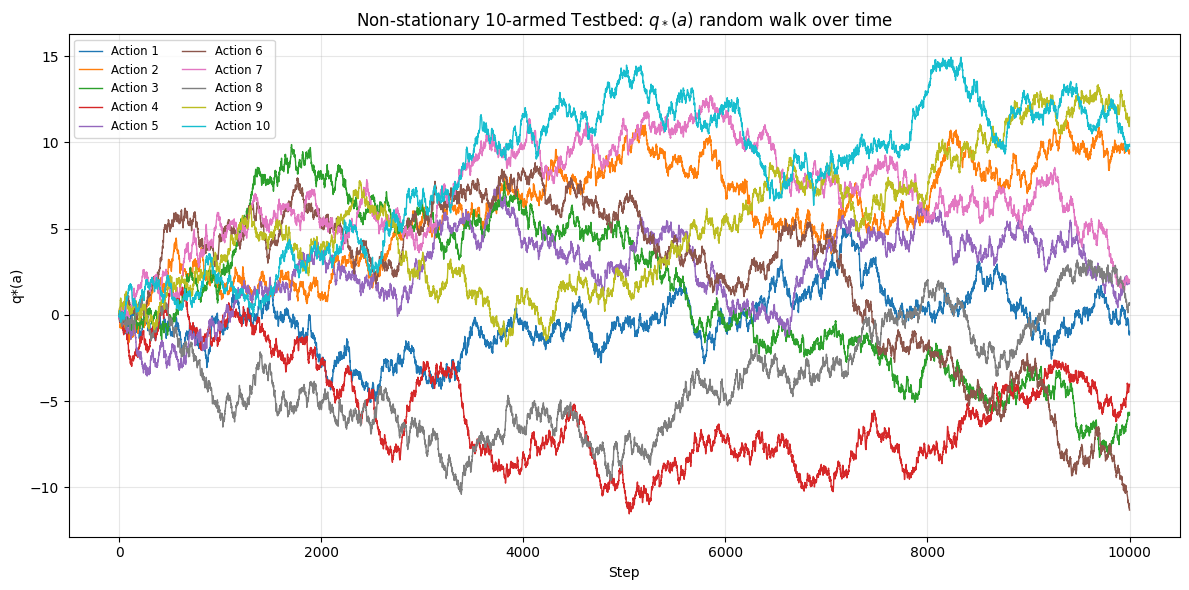

In [6]:
# 模拟并绘制非平稳10臂测试平台中每个动作真实价值 q*(a) 的随机游走曲线
# 依赖已在笔记本中导入的 np, plt, sns

rw_steps = 10000           # 演化步数（可调整）
sigma_rw = np.sqrt(0.01)  # 随机游走的标准差（方差为0.01）
n_arms = 10               # 臂数（笔记本中已有 n_arms，可重用）

np.random.seed(123)       # 为可复现性设种子（可移除以获得不同轨迹）

# 初始化所有动作的初始真实价值相等（例如都为0）
q = np.zeros(n_arms)
q_history = np.zeros((rw_steps, n_arms))

for t in range(rw_steps):
    # 每个动作独立做一次正态噪声随机游走增量
    q += np.random.normal(0.0, sigma_rw, size=n_arms)
    q_history[t] = q

# 绘图：每个动作一条线
plt.figure(figsize=(12, 6))
palette = sns.color_palette("tab10", n_arms)
for a in range(n_arms):
    plt.plot(q_history[:, a], label=f'Action {a+1}', color=palette[a], linewidth=1)

plt.title('Non-stationary 10-armed Testbed: $q_*(a)$ random walk over time')
plt.xlabel('Step')
plt.ylabel('q*(a)')
plt.legend(loc='upper left', ncol=2, fontsize='small')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

针对非平稳 10 臂测试平台，使用 ε-贪婪 + 固定步长 α的模拟程序算法如下：

- 准备阶段：加载 q_history（每步的真实 q*(a) 随时间变化），并设置超参数 α、ε（这里以 eps_use 表示）、runs_sim（独立试验次数）和 T（实际模拟步数，取 steps 与 q_history 长度的最小值）。
- 外层循环（重复 runs_sim 次独立试验）：
    - 每次试验初始化估计值 Q_est 为全零（长度为 n_arms）。
    - 时间步循环 t = 0 .. T-1：
        - 以概率 ε 进行探索：随机选择一个动作；否则进行利用：选择当前 Q_est 最大的动作（若并列则在并列动作中随机选择）。
        - 根据当前时刻的真实值 q_history[t, action]，从正态分布 N(q_history[t, action], 1) 中采样得到 reward_t。
        - 使用固定步长 α 做增量更新：Q_est[action] += α * (reward_t - Q_est[action])，以便对非平稳目标快速响应。
        - 记录本步的 reward（存入 rewards_all_nonstat）并判断所选动作是否等于当时真实 q_history 的最优臂（将结果记录到 optimal_chosen_nonstat）。
- 多次试验后：对 runs_sim 次试验在每个时间步上取平均，得到 avg_reward_nonstat（平均回报随时间）和 percent_optimal_nonstat（每步选择最优动作的百分比）。
- 可视化：绘制两张子图，分别展示随时间变化的平均回报和选择最优动作的百分比，用以评估在非平稳环境下不同参数（α、ε）下算法的跟踪能力与性能。


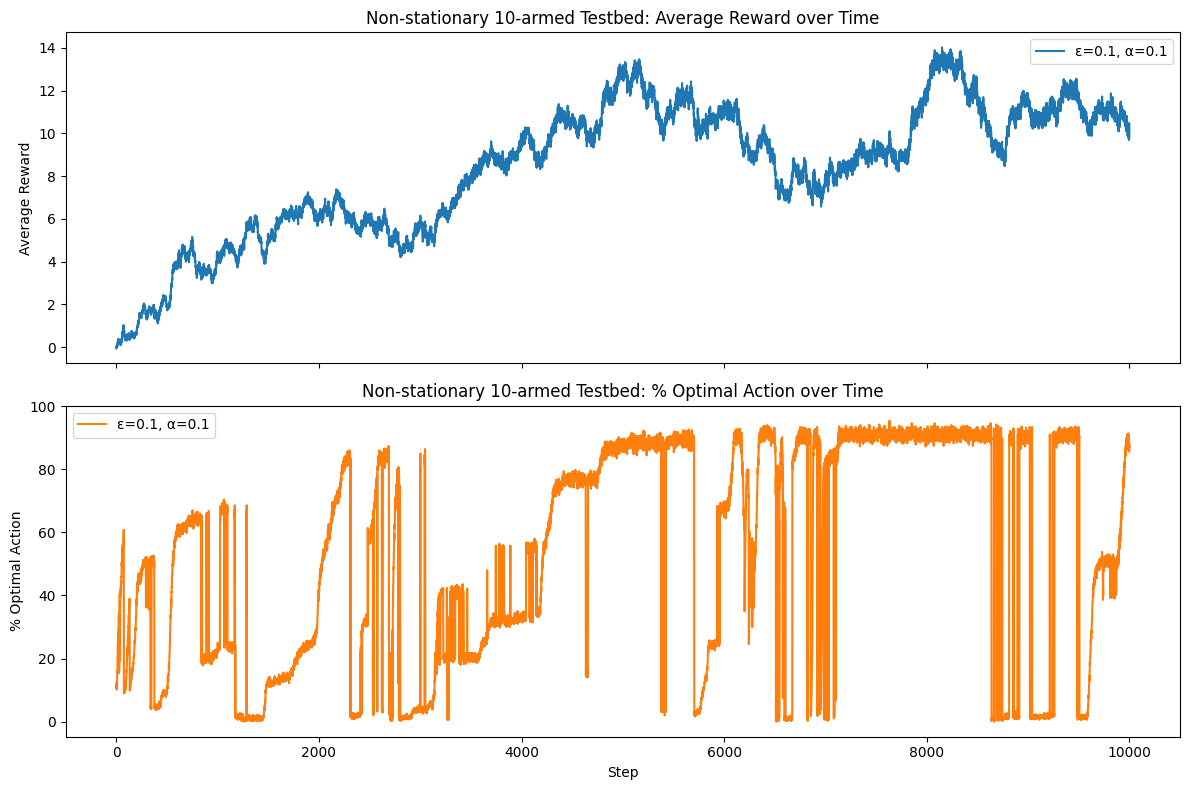

In [7]:
# 在非平稳10臂测试平台上，用 ε-贪婪（固定步长α）跟踪并绘制平均回报与%最优动作随时间的曲线
# 使用笔记本已有变量：q_history, n_arms, steps, eps (作为ε)
# 注意避免覆盖已有重要变量名，使用局部变量名 Q_est 等

alpha = 0.1
eps_use = eps  # 使用笔记本中已有的 eps（例如 0.1）
runs_sim = 500  # 为了速度/可视化平滑，选取一定数量的独立试验；可根据需要增大
T = min(steps, q_history.shape[0])

rewards_all_nonstat = np.zeros((runs_sim, T))
optimal_chosen_nonstat = np.zeros((runs_sim, T))

for run_idx in range(runs_sim):
    Q_est = np.zeros(n_arms)  # 估计值，针对每个试验独立初始化
    for t in range(T):
        # 选择动作（ε-贪婪）
        if np.random.rand() < eps_use:
            action_t = np.random.randint(n_arms)
        else:
            best_idxs = np.flatnonzero(Q_est == Q_est.max())
            action_t = int(np.random.choice(best_idxs)) if best_idxs.size > 1 else int(best_idxs[0])

        # 环境按当前时刻的真实 q*(a)（来自 q_history）采样奖励，方差1
        reward_t = np.random.normal(q_history[t, action_t], 1.0)

        # 固定步长的增量更新（用于非平稳情况）
        Q_est[action_t] += alpha * (reward_t - Q_est[action_t])

        rewards_all_nonstat[run_idx, t] = reward_t

        # 每个时刻的最优动作由 q_history 当时刻的最大值决定
        optimal_action_at_t = int(np.argmax(q_history[t]))
        optimal_chosen_nonstat[run_idx, t] = 1 if action_t == optimal_action_at_t else 0

# 对多次试验取平均
avg_reward_nonstat = rewards_all_nonstat.mean(axis=0)
percent_optimal_nonstat = optimal_chosen_nonstat.mean(axis=0) * 100.0

# 绘图（上：平均回报；下：%最优动作）
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(avg_reward_nonstat, color='tab:blue', label=f'ε={eps_use}, α={alpha}')
ax[0].set_ylabel('Average Reward')
ax[0].set_title('Non-stationary 10-armed Testbed: Average Reward over Time')
ax[0].legend()

ax[1].plot(percent_optimal_nonstat, color='tab:orange', label=f'ε={eps_use}, α={alpha}')
ax[1].set_xlabel('Step')
ax[1].set_ylabel('% Optimal Action')
ax[1].set_title('Non-stationary 10-armed Testbed: % Optimal Action over Time')
ax[1].legend()

plt.tight_layout()
plt.show()

## 乐观初始值

### 什么是强化学习中的“乐观初始值”？
在基于样本均值或增量更新的动作价值估计中，所谓“乐观初始值”是指将每个动作的初始估计 $Q_1(a)$ 设得比真实期望更高（例如把所有 $Q_1(a)$ 初始化为一个较大的 $Q_0$），这样未被尝试的动作在初期显得格外有吸引力，能够在没有显式 ε-随机探索的情况下驱动算法优先尝试各个动作以“验证”这些乐观估计；当观测到的回报低于 $Q_0$ 时，相应动作的估计会下降，从而自然地产生探索行为。

### 在十臂测试平台上的作用与机制
在十臂测试平台中，将每个动作的初始估计 $Q_1(a)$ 设为较大的 $Q_0$ 会使算法（尤其是纯贪婪 ε=0）在早期主动遍历各臂以验证这些乐观估计：每次尝试若观测回报低于 $Q_0$，该臂的估计值会随之下降，反之则被保留为候选优选。此法的优点在于可以在零或很小 ε 的情形下实现有效的早期探索，减少随机探索带来的短期回报波动，且实现非常简单 —— 只需调整初始化而无需引入额外的概率机制。缺点是它依赖于对奖励尺度的合理假设：若 $Q_0$ 设得过高，会导致过度探索和较长时间的试错成本；若 $Q_0$ 太低，则难以产生显著效果；在非平稳环境中，乐观初始值的益处会很快被后续更新覆盖，甚至引入滞后与高方差问题。相比基于不确定性的策略，乐观初始化更为经验化和粗糙，通常作为一种简单的启发式手段与衰减 ε、固定步长 α 等方法配合使用以取得更稳健的效果。

### 乐观初始值与 ε-贪婪、衰减 ε的比较
乐观初始值与 ε-贪婪和衰减 ε 在探索机制上有所不同。固定 ε 的 ε-贪婪通过以恒定概率随机选择动作来保证均匀的探索，而乐观初始化则通过人为抬高未尝试动作的初始估计诱导算法在早期优先尝试这些动作，从而在实验初期能部分替代或补充固定 ε 的作用；相比之下，衰减 ε 则是在时间上可控地从强探索过渡到强利用，适合需要在早期大量探索并在后期稳定利用的场景，因此在可控性和长期表现上通常比单纯依赖乐观初始值更稳健。

在十臂测试平台中的实践应用中，如果问题是平稳且希望简单实现早期探索，可以尝试将初始值 $Q_0$ 设为 1 到 5（具体取决于奖励尺度），并可与很小的 ε（甚至 ε=0）配合使用，通过观察早期的平均回报与优化曲线来调整 $Q_$0$ 以避免过度试错；如果问题是非平稳，则应优先使用固定步长 α（如 0.1 或更小）并配合适度的 ε 或衰减 ε 而非依赖乐观初始值。

乐观初始值是一种通过把 $Q_1(a)$ 设高来诱导探索的简单技巧，在静态的多臂问题（如标准十臂测试平台）上能显著提高早期探索效率；但选择合适的初始值依赖于奖励尺度，且在非平稳环境中效果有限或不合适。常与 ε-贪婪、衰减 ε 或固定步长更新结合使用，根据具体问题权衡使用。



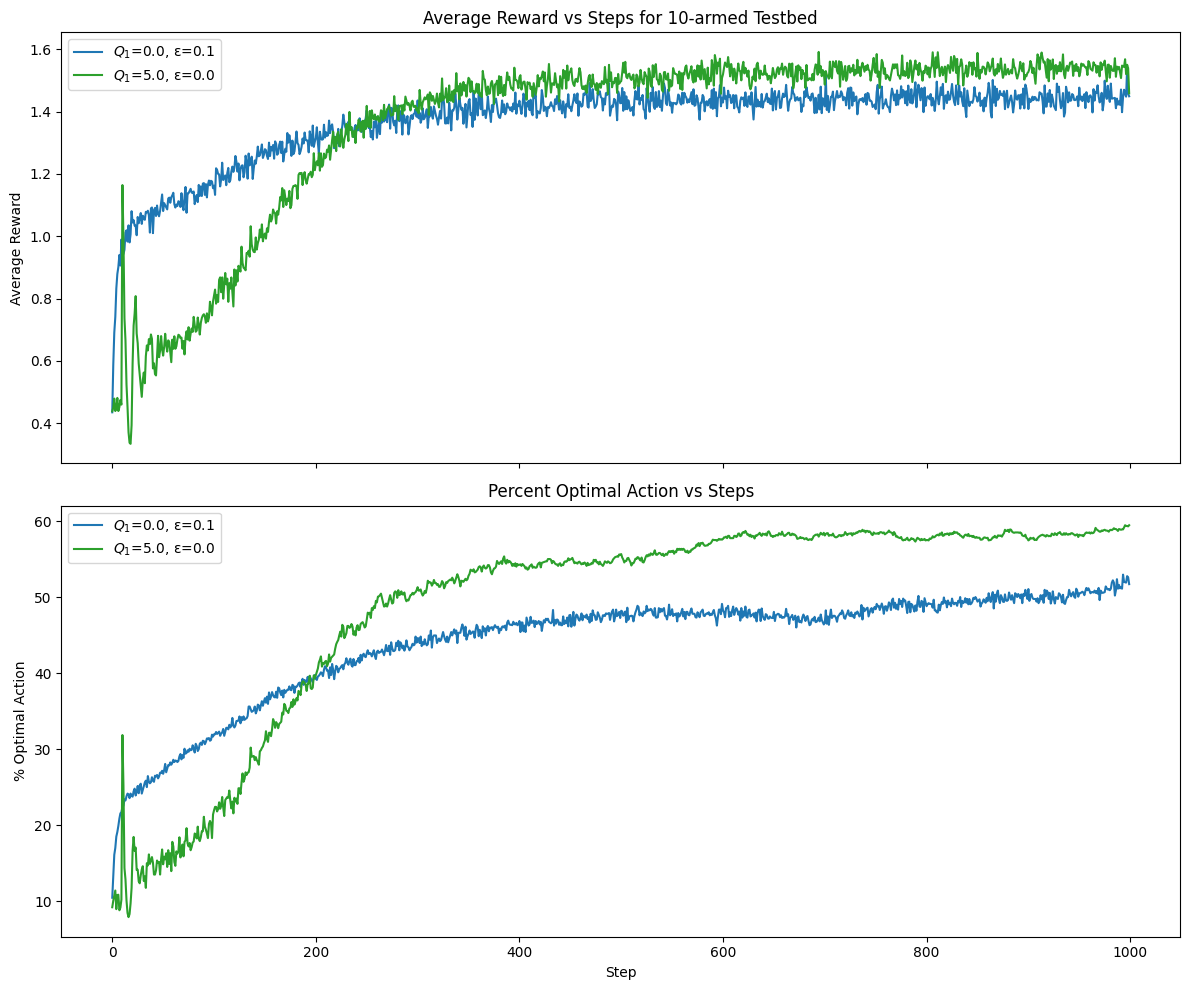

In [8]:
import numpy as np
import matplotlib.pyplot as plt


# 生成10个动作的真实价值 q*(a)，从均值0，方差1的正态分布中采样
np.random.seed(42)  # 设置随机种子以便重现
n_arms = 10 # 动作数
means = np.random.normal(0, 1, n_arms)        
optimal_arm = int(np.argmax(means))

def run_epsilon_greedy(eps=0.0, Q1=0.0, alpha=0.1, runs=2000, steps=1000):
    """
    eps: ε值
    Q1: 初始 Q 值（默认0.0，可设为乐观初始值）
    alpha: 步长
    steps：每次运行的步数
    runs：用于平均的独立运行次数
    对于给定的 eps 值和初始 Q 值 Q1，运行 ε-贪婪算法。
    返回：avg_rewards（长度为 steps），optimal_action_rates（长度为 steps，百分比）
    """
    rewards_all = np.zeros((runs, steps))
    optimal_chosen = np.zeros((runs, steps))
    for run in range(runs):
        Q = np.zeros(n_arms) + Q1  # 使用乐观/指定初始值 
        N = np.zeros(n_arms)
        for t in range(steps):
            if np.random.rand() < eps:
                action = np.random.randint(n_arms)
            else:
                best = np.flatnonzero(Q == Q.max())
                action = int(np.random.choice(best)) if best.size > 1 else int(best[0])
            reward = np.random.normal(means[action], 1.0)
            N[action] += 1
            Q[action] += alpha * (reward - Q[action])

            rewards_all[run, t] = reward
            optimal_chosen[run, t] = 1 if action == optimal_arm else 0

    avg_rewards_single = rewards_all.mean(axis=0)
    optimal_action_rates_single = optimal_chosen.mean(axis=0) * 100.0
    return avg_rewards_single, optimal_action_rates_single

# 绘图：两个子图，上：平均回报；下：选择最优动作的百分比
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

eps = 0.1
Q1 = 0.0
avg_rewards, optimal_action_rates = run_epsilon_greedy(eps, Q1=Q1, runs=2000, steps=1000)
axes[0].plot(avg_rewards, label=f'$Q_1$={Q1}, ε={eps}', color='tab:blue')
axes[1].plot(optimal_action_rates, label=f'$Q_1$={Q1}, ε={eps}', color='tab:blue')

eps = 0.0
Q1 = 5.0
avg_rewards, optimal_action_rates = run_epsilon_greedy(eps, Q1=Q1, runs=2000, steps=1000)
axes[0].plot(avg_rewards, label=f'$Q_1$={Q1}, ε={eps}', color='tab:green')
axes[1].plot(optimal_action_rates, label=f'$Q_1$={Q1}, ε={eps}', color='tab:green')


axes[0].set_ylabel('Average Reward')
axes[0].set_title('Average Reward vs Steps for 10-armed Testbed')
axes[0].legend()

axes[1].set_xlabel('Step')
axes[1].set_ylabel('% Optimal Action')
axes[1].set_title('Percent Optimal Action vs Steps')
axes[1].legend()

plt.tight_layout()


上图展示了使用固定步长（α=0.1）算法对2000次独立实验结果求平均后的曲线。对于采用乐观初始值（如 Q1=5）的情形，早期出现明显的振荡与尖峰；由于已对2000次运行求平均，这些波动并非随机噪声，而是乐观初始化引发的系统性动态：初始估计值过高促使算法在早期大量尝试这些动作，随后在观测到较低回报时迅速下调估计，从而产生显著的短期波动。该现象是可解释且与探索机制密切相关。

## 上置信界（Upper-Confidence-Bound, UCB）动作选择

上置信界（UCB）动作选择的思想是根据动作的估计价值以及这些估计的不确定性或方差来选择动作。
UCB 算法通过选择估计值高或不确定性大的动作来平衡探索与利用，从而鼓励对那些较少被选择的动作进行探索。
其中一个有效计算上置信界的公式为：
$$A_t = \arg\max_a\left[Q_t(a)+c\sqrt{\frac{\ln t}{N_t(a)}}\right]$$

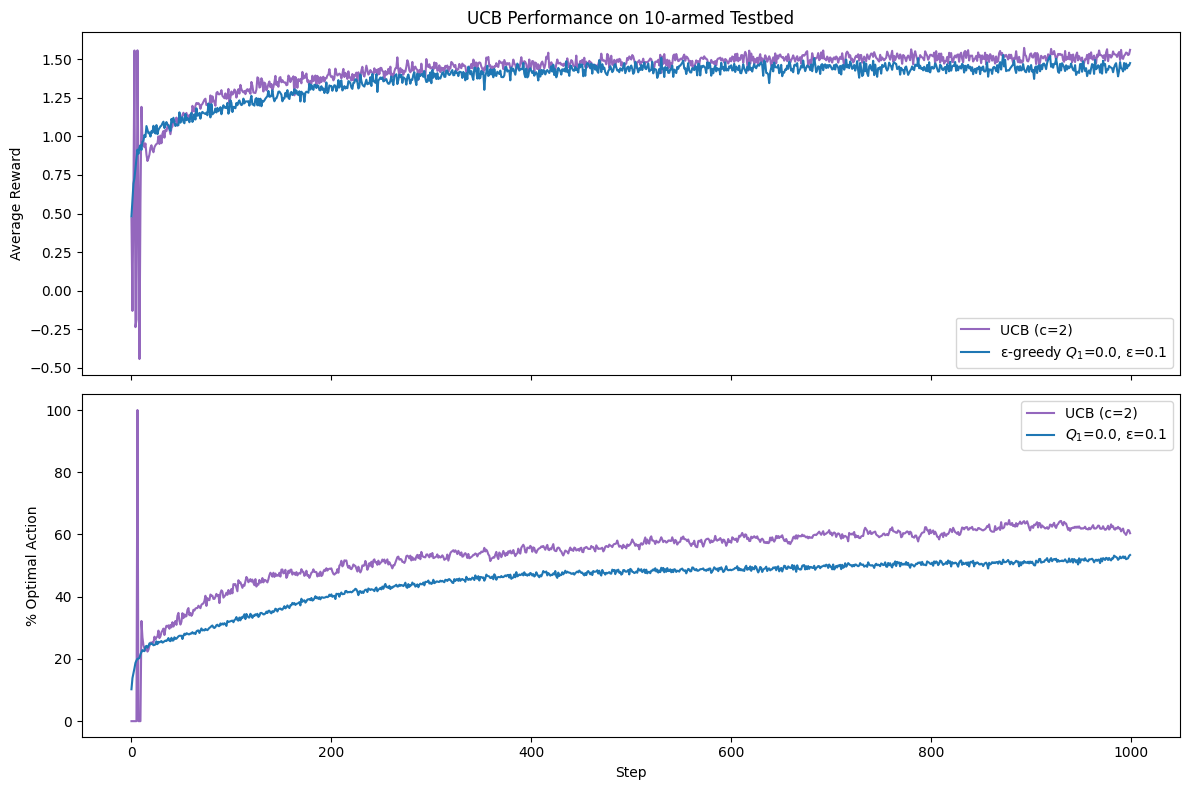

In [9]:
# 上置信界（UCB）方法实现与演示
# 说明（注释内为中文）：UCB 在每一步选择使得 Q(a) + c * sqrt( ln t / N(a) ) 最大的动作，
# 其中第二项为不确定性项，c 控制探索强度。若某臂尚未被尝试，则优先尝试（UCB 设为 +inf）。

import numpy as np
import matplotlib.pyplot as plt


# 生成10个动作的真实价值 q*(a)，从均值0，方差1的正态分布中采样
np.random.seed(42)  # 设置随机种子以便重现
n_arms = 10 # 动作数
means = np.random.normal(0, 1, n_arms)        
optimal_arm = int(np.argmax(means))

def run_ucb(c=2.0, runs=2000, steps=1000):
    rewards_all = np.zeros((runs, steps))
    optimal_chosen = np.zeros((runs, steps))
    for run in range(runs):
        Q = np.zeros(n_arms)      # 价值估计
        N = np.zeros(n_arms)      # 选择计数
        for t in range(steps):
            # 若还有未被尝试的臂，优先尝试它们（保证初始覆盖）
            if (N == 0).any():
                # 选择第一个未被尝试的臂（也可以随机未尝试臂）
                action = int(np.flatnonzero(N == 0)[0])
            else:
                # 计算 UCB 值并选择最大者
                confidence = c * np.sqrt(np.log(t + 1) / N)
                ucb_values = Q + confidence
                action = int(np.argmax(ucb_values))

            reward = np.random.normal(means[action], 1.0)
            N[action] += 1
            # 使用样本均值增量更新（也可用固定步长）
            Q[action] += (reward - Q[action]) / N[action]

            rewards_all[run, t] = reward
            optimal_chosen[run, t] = 1 if action == optimal_arm else 0

    avg_rewards_ucb = rewards_all.mean(axis=0)
    percent_optimal_ucb = optimal_chosen.mean(axis=0) * 100.0
    return avg_rewards_ucb, percent_optimal_ucb

# 运行并绘图（示例：c=2）
avg_ucb, opt_ucb = run_ucb(c=2.0, runs=2000, steps=1000)

eps = 0.1
Q1 = 0.0
avg_greedy, opt_greedy = run_epsilon_greedy(eps, Q1=Q1, runs=2000, steps=1000)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(avg_ucb, label='UCB (c=2)', color='tab:purple')
axes[0].plot(avg_greedy, label=f'ε-greedy $Q_1$={Q1}, ε={eps}', color='tab:blue')

axes[0].set_ylabel('Average Reward')
axes[0].set_title('UCB Performance on 10-armed Testbed')
axes[0].legend()

axes[1].plot(opt_ucb, label='UCB (c=2)', color='tab:purple')
axes[1].plot(opt_greedy, label=f'$Q_1$={Q1}, ε={eps}', color='tab:blue')

axes[1].set_xlabel('Step')
axes[1].set_ylabel('% Optimal Action')
axes[1].legend()

plt.tight_layout()
plt.show()

从上图可见，UCB 在许多情形下表现良好，参数 c 用于控制探索强度，c 越大探索越强（常见取值如 1、2、5，可通过实验对比选择）。
由于 UCB 会优先尝试不确定或较少被选择的臂，在平稳环境中通常表现突出；
而在非平稳场景下，常需结合折扣或固定步长更新，或采用滑动窗口统计等机制，以维持对漂移的跟踪能力。
但将UCB其直接推广到更广泛的强化学习场景并不容易：一方面，它对非平稳环境不敏感；另一方面，在状态空间极大时扩展性受限。

## 梯度赌博机（Gradient Bandit）算法

本节我们考虑为每个动作 $a$ 学习一个数值偏好（preference），记为 $H_t(a)$。
偏好越大，采取这个动作的可能性就越大。
我们计算这个概率一般采用softmax分布（例如Gibbs或者玻尔兹曼分布）：
$$\Pr{\{A_t=a\}}=\frac{e^{H_t(a)}}{\sum_{b=1}^k e^{H_t(b)}}=\pi_t(a)$$
如果只有两个动作，那么softmax分布等价于sigmoid:
$$\Pr{\{A_t=a\}}=\frac{1}{1+ e^{-H_t(a)}}$$
参考随机梯度下降法，我们可以得到一个新的算法。
对于每一步，选择了一个动作$A_t$和得到一个收益$R_t$后，新的动作偏好可以由以下公式计算得到：
$$H_{t+1}(A_t) = H_t(A_t) + \alpha (R_t - \hat{R}_t)(1-\pi_t(A_t))$$
对于其他$a\ne A_t$，我们有：
$$H_{t+1}(a) = H_t(a) - \alpha (R_t - \hat{R}_t)\pi_t(a)$$


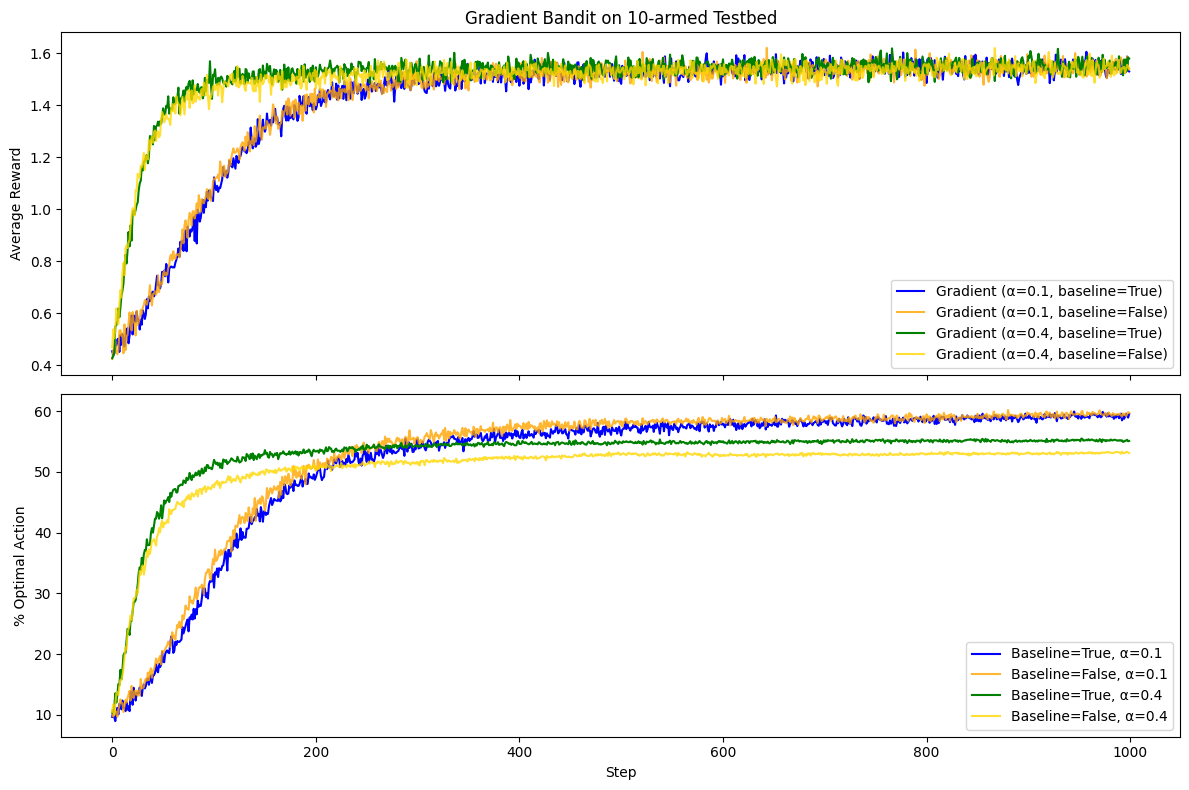

In [10]:
# Gradient bandit algorithm (Gradient Bandit / REINFORCE-style) for 10-armed testbed
# 依赖笔记本中已存在的变量：np, plt, n_arms, means, optimal_arm
# 使用方法示例：avg_g_baseline, opt_g_baseline = run_gradient_bandit(alpha=0.1, baseline=True, runs=2000, steps=1000)

def _softmax(x):
    x = x - np.max(x)  # numeric stability
    ex = np.exp(x)
    return ex / np.sum(ex)

def run_gradient_bandit(alpha=0.1, baseline=True, runs=2000, steps=1000):
    """
    alpha: 学习率 (步长) 用于偏好 H 的更新
    baseline: 是否使用回报基线（每次试验内的平均回报）
    runs: 独立重复试验次数（用于求平均）
    steps: 每次试验的时间步长
    返回：
      avg_rewards: 每个时间步的平均回报（长度 steps）
      percent_optimal: 每个时间步选择最优动作的百分比（长度 steps）
    """
    rewards_all = np.zeros((runs, steps))
    optimal_chosen = np.zeros((runs, steps))

    for run in range(runs):
        H = np.zeros(n_arms)         # 偏好
        avg_r = 0.0                  # 试验内的回报均值（baseline）
        for t in range(steps):
            pi = _softmax(H)
            action = np.random.choice(n_arms, p=pi)
            reward = np.random.normal(means[action], 1.0)

            baseline_val = avg_r if baseline else 0.0

            # 向量化的偏好更新： H += alpha * (R - baseline) * (I[a] - pi)
            one_hot = np.zeros(n_arms)
            one_hot[action] = 1.0
            H += alpha * (reward - baseline_val) * (one_hot - pi)

            # 更新试验内平均回报（用于下一步的 baseline）
            avg_r += (reward - avg_r) / (t + 1)

            rewards_all[run, t] = reward
            optimal_chosen[run, t] = 1 if action == optimal_arm else 0

    avg_rewards = rewards_all.mean(axis=0)
    percent_optimal = optimal_chosen.mean(axis=0) * 100.0
    return avg_rewards, percent_optimal

# 快速演示与绘图：比较带 baseline 与不带 baseline 的效果
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

runs_demo = 2000
steps_demo = 1000

alph = 0.1
avg_b, opt_b = run_gradient_bandit(alpha=alph, baseline=True, runs=runs_demo, steps=steps_demo)
avg_nb, opt_nb = run_gradient_bandit(alpha=alph, baseline=False, runs=runs_demo, steps=steps_demo)

axes[0].plot(avg_b, label=f'Gradient (α={alph}, baseline=True)', color='blue')
axes[0].plot(avg_nb, label=f'Gradient (α={alph}, baseline=False)', color='orange', alpha=0.8)
axes[1].plot(opt_b, label=f'Baseline=True, α={alph}', color='blue')
axes[1].plot(opt_nb, label=f'Baseline=False, α={alph}', color='orange', alpha=0.8)

alph = 0.4
avg_b, opt_b = run_gradient_bandit(alpha=alph, baseline=True, runs=runs_demo, steps=steps_demo)
avg_nb, opt_nb = run_gradient_bandit(alpha=alph, baseline=False, runs=runs_demo, steps=steps_demo)

# 'tab:yellow' is not a valid matplotlib color; replace with a standard color name
axes[0].plot(avg_b, label=f'Gradient (α={alph}, baseline=True)', color='green')
axes[0].plot(avg_nb, label=f'Gradient (α={alph}, baseline=False)', color='gold', alpha=0.8)
axes[1].plot(opt_b, label=f'Baseline=True, α={alph}', color='green')
axes[1].plot(opt_nb, label=f'Baseline=False, α={alph}', color='gold', alpha=0.8)

axes[0].set_ylabel('Average Reward')
axes[0].set_title('Gradient Bandit on 10-armed Testbed')
axes[0].legend()


axes[1].set_xlabel('Step')
axes[1].set_ylabel('% Optimal Action')
axes[1].legend()

plt.tight_layout()
plt.show()

上图是在10臂测试平台上，使用梯度带臂算法（Gradient Bandit / REINFORCE-style）时，比较使用回报基线（baseline）与不使用回报基线的效果。可以看出，使用回报基线的算法在收敛速度和最终性能上都优于不使用回报基线的算法。

## PyTorch 实现的 ε-贪婪、UCB与梯度赌博机

###  ε-贪婪、UCB与梯度赌博机算法对比

ε-贪婪是一种直接且直观的方法：以概率 $1-\varepsilon$ 选择当前估计最优的动作，以概率 $\varepsilon$ 随机探索。价值估计的更新可以采用样本均值
$$Q_{n+1}(a)=Q_n(a)+\frac{1}{N(a)}\big(R_n-Q_n(a)\big)$$
或使用固定步长
$$Q_{n+1}(a)=Q_n(a)+\alpha\big(R_n-Q_n(a)\big)$$
以适应非平稳环境。ε-贪婪的优点在于实现和理解都非常简单，参数少，易于并行化和调试；缺点在于探索是均匀随机的——它不会优先探索“不确定性更大”或“潜在回报更高”的动作，因此在有大量臂或奖励分布差异明显时可能浪费探索预算。ε 的选取决定了探索频率：较大的 ε 助于早期发现好臂但会降低短期回报，常见实践包括用衰减的 ε 随时间减小，或结合乐观初始值以在早期诱导探索而减少随机性。

上置信界（UCB）方法通过在估计值上加一个与不确定性成比例的置信项来选择动作，常见形式为
$$A_t=\arg\max_a\Big[Q_t(a)+c\sqrt{\frac{\ln t}{N_t(a)}}\Big].$$
UCB 的探索是有目的的：它优先去尝试那些既可能好又不确切的臂，理性地平衡利用与探索，从理论上在平稳多臂环境中有渐近的上界保证。优点是探索较有效、样本利用率高，缺点是在非平稳场景下易失效（因置信项依赖于累计计数 $N_t(a)$），且需要设定常数 $c$ 来调节探索强度；在实现上需要在每步计算置信项（$O(k)$），对臂数很大时需注意计算成本与数值稳定性。

梯度赌博机（Gradient Bandit）直接对策略进行参数化：为每个动作维护偏好 $H(a)$，通过 softmax 得到采样概率 $\pi(a)$，然后基于回报做随机梯度上升，常用更新为
$$H_{t+1}(A_t)=H_t(A_t)+\alpha\,(R_t-\hat R_t)\,(1-\pi_t(A_t)),\quad H_{t+1}(a)=H_t(a)-\alpha\,(R_t-\hat R_t)\,\pi_t(a)\ (a\ne A_t),$$
或向量化为 $H_{t+1}=H_t+\alpha(R_t-\hat R_t)(e_{A_t}-\pi_t)$。梯度方法的优势在于它直接优化策略、天然输出概率化策略，便于与函数逼近和策略梯度框架（如 REINFORCE、Actor-Critic）对接；使用 baseline（如试验内平均回报 $\hat R_t$）能显著降低方差并稳定学习。它的缺点是通常对学习率 $\alpha$ 比较敏感，更新的方差仍比价值基方法高，且 softmax 采样会在极端偏好下导致概率饱和，需数值稳定处理（如减去最大值）与可能的正则化或剪裁。

从探索行为与样本效率角度比较，UCB 在平稳问题上往往比 ε-贪婪更高效，因为它以不确定性驱动探索；ε-贪婪更为鲁棒、实现更简单且容易用乐观初始值补偿早期探索；梯度方法则适用于需要概率策略、可微的策略表示或后续要与神经网络连用的场景，但在纯粹的多臂测试床上它的方差和对α的敏感度需要仔细调参。若问题是非平稳的，应优先选择使用固定步长的 ε-贪婪或在 UCB/梯度方法中引入折扣、滑窗或重置机制；对于 UCB，可考虑使用衰减计数或基于时间窗口的置信估计以提高对漂移的响应。

在复杂度和工程实现上，ε-贪婪每步选择代价低（查找最大或随机选择，若并行批量化可非常高效），UCB 每步需要计算置信项（$O(k)$）且需维护计数，梯度赌博机需要计算 softmax 并做指数运算（$O(k)$），在使用 PyTorch 时这三者都能被张量化以并行运行大量独立试验；但要注意设备管理、dtype、随机数种子与可复现性，GPU 加速尤其对 runs 很大时更为划算，而对小规模实验 PyTorch 的调度开销可能让 NumPy 实现更快。

在超参数调优与实践建议上，ε-贪婪 的 ε 值常从 0.01–0.1 试起，若希望早期探索更强可以用衰减策略或乐观初始值；UCB 的 $c$ 常在 1–5 之间调试，值越大探索越强；梯度赌博机的 α 一般比价值算法的步长要小心选择，常从 0.01 开始并结合 baseline 使用以降低方差。无论哪种算法，先在小规模 runs/steps 做 smoke test 检查概率归一性、偏好或估计的边界行为、以及在极端参数下是否发生饱和或发散，是高质量实验流程的必备步骤。

总体而言，如果目标是快速对比基线算法且关注实现简单性，ε-贪婪（配合乐观初始或衰减 ε）是首选；若问题是平稳且追求高样本效率与理论保证，UCB 常是更好的选择；若希望输出概率策略、后期与神经网络或策略梯度方法结合，梯度赌博机提供最自然的接入点。实验时可把三者放在同一组真实值与随机种子下做并行比较，记录平均回报与 % 最优动作随时间的曲线，从而在特定问题上做出有数据支持的选择。
下面以教科书式的叙述说明：用 PyTorch 实现这些多臂/策略算法（ε-贪婪、UCB、梯度赌博机）带来的主要优点与缺点，并给出若干实践层面的注意与缓解建议。

### Pytorch实现的优缺点

PyTorch 首先提供的是高性能的张量计算引擎，能够把大量独立重复试验（runs）或并行样本的计算向量化并迁移到 GPU，从而在做大规模仿真实验时显著缩短运行时间。相比逐步的 Python 循环，张量化实现能把相同逻辑在数千次试验上一次性并行执行，利用 SIMD/GPU 并行的吞吐优势，这对做参数扫描与统计平均尤其重要。  

其次，PyTorch 的自动微分和模块化 API 使得从简单的带臂基线算法平滑过渡到带函数逼近的策略梯度、Actor–Critic 或神经网络策略变得自然和低成本：你可以把偏好/策略用神经网络参数化，直接调用优化器来训练，这在研究中非常方便。  

再者，PyTorch 提供统一的设备管理（CPU/GPU）、随机种子控制接口和成熟的序列化（保存/加载模型）机制，这有助于实验可移植性、复现和结果保存。框架周边的生态（profiler、tensorboard、集成优化器、数据并行工具）也方便进行性能调优与实验管理。  

最后，PyTorch 社区和文档丰富，对于遇到数值、并行或调参问题时，查找资料和示例也更容易，这对工程化实验非常有利。

PyTorch 并不是万能的：对于小规模、教学演示或快速探索性实验，引入 PyTorch 的依赖和调度开销反而会使单次运行更慢。框架的启动、张量在 CPU/GPU 之间拷贝、以及某些小规模操作的调度延迟，会让短小实验的延时变大。  

在实现复杂性上，使用 PyTorch 要额外管理 dtype、device（CPU/GPU）、随机性（torch 与 numpy 的种子）以及可能的非确定性操作。特别是在 GPU 上，某些实现（例如 cuDNN 的某些内核）默认是非确定性的，要严格复现结果需要额外设置并接受性能折中。若不小心还可能引入隐蔽错误：比如无意间在不同试验间复用张量导致状态共享、或在向量化实现时出现维度/广播错误而难以调试。  

内存消耗是另一项需要注意的代价：把大量 runs 和步长打包到一个大张量会占用大量 GPU/CPU 内存，必要时必须使用批次或分块策略。并且，默认的浮点精度（float32）在某些极端累积计算中可能带来数值稳定性问题，改用 float64 会进一步增加内存与计算开销。  

最后，框架升级、API 变化或 CUDA 兼容问题可能造成环境维护成本，比起单纯用 NumPy 的“零依赖”脚本需要更多的运维注意。

在使用 PyTorch 实现这些算法时，首先在小规模上做 smoke test（和已知的 NumPy 实现或手算结果比对），确保逻辑与指标一致，再把实现向量化或搬到 GPU。若追求可复现性，请同时设置 torch.manual_seed、numpy.random.seed，并在需要严格确定性时开启 torch.backends.cudnn.deterministic=True 与 torch.use_deterministic_algorithms(True)（但要注意这可能降低性能或限制某些操作）。  

内存管理方面，避免一次性把非常大的 runs×steps 张量全放到 GPU，使用按批次的向量化或把 runs 拆分成若干批次来累积统计量。向量化实现时要小心不要共用可变张量；对每个独立试验应使用独立的状态张量或在循环中重置状态。对 softmax、指数等敏感操作采用数值稳定技巧（例如减去最大值），并在梯度方法中对 learning rate 做充分的网格搜索与早期监控，必要时引入梯度裁剪或 L2 正则化以防偏好爆炸。  

在追求性能时，使用 profiler 先定位瓶颈（是数据拷贝、随机采样、还是张量操作），并尽量把数据生成、采样与更新保持在同一 device 上以避免往返拷贝。对于需要严格可重复的结果，在 GPU 上可能需要放弃某些最快但非确定性内核，或在关键实验中转回 CPU 以得到可比的确定性基线。

如果你的目标是做严肃的、可扩展的实验（大量 runs、参数搜索、或计划把策略与神经网络结合），那么用 PyTorch 实现这些算法的收益明显且长期价值高：你获得了可扩展性、GPU 加速和与深度模型无缝集成的能力。相反，如果你的目的只是教学演示、小规模验证或快速原型，并不打算扩展到函数逼近或大规模统计，采用轻量的 NumPy 实现会更简洁、可读且更易于即时交互。选择时把实验规模、是否需要 GPU、可复现性要求以及后续扩展路径都纳入考虑。

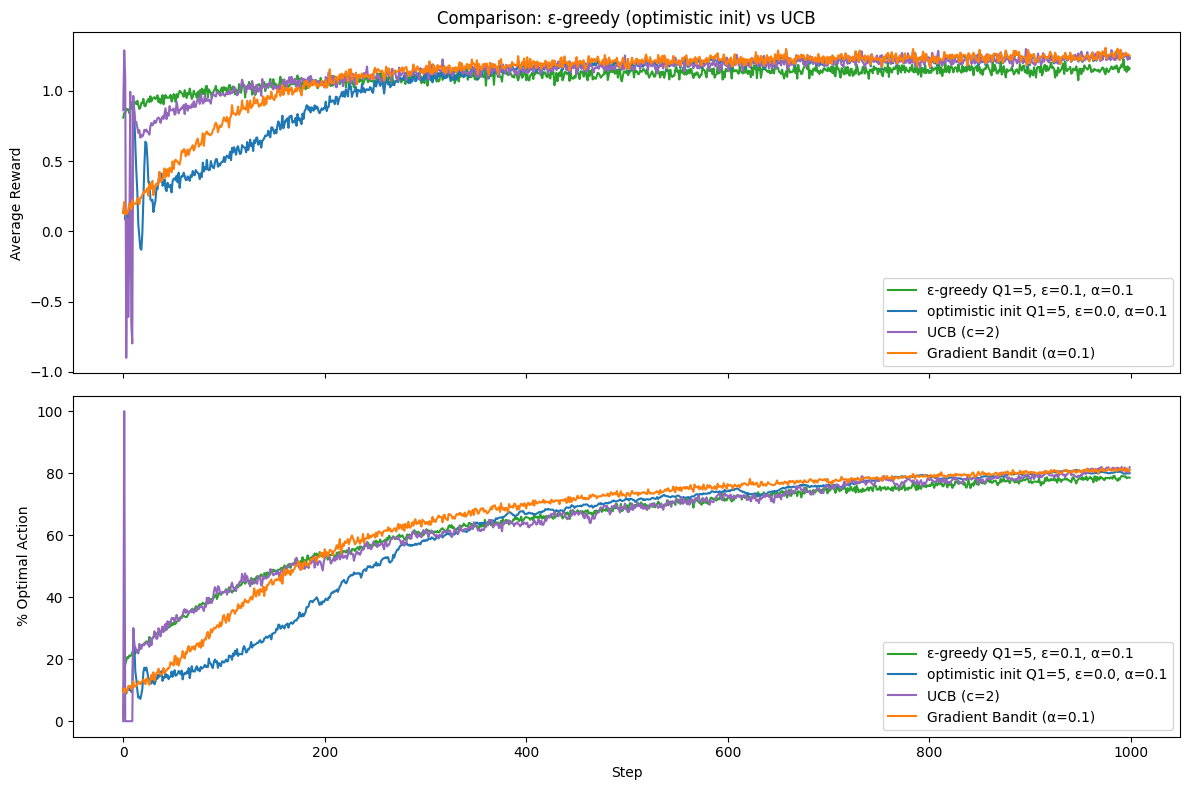

In [1]:
# Batch-parallel implementations for bandit algorithms using PyTorch
# Add `batch` parameter: at each outer loop iteration we run `batch` independent runs in parallel
import torch
import numpy as np
import matplotlib.pyplot as plt

def run_epsilon_greedy_torch_batch(means, epsilon=0.1, runs=2000, steps=1000, batch=100, seed=None, device='cpu'):
    """Batch-parallel epsilon-greedy using PyTorch.
    Runs are processed in chunks of size `batch` to reduce Python loop overhead.
    """
    if isinstance(means, (list, np.ndarray)):
        means = torch.tensor(means, dtype=torch.float32, device=device)
    else:
        means = means.to(device).float()

    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(int(seed))

    n_arms = means.shape[0]
    avg_rewards_acc = torch.zeros(steps, dtype=torch.float32, device=device)
    optimal_acc = torch.zeros(steps, dtype=torch.float32, device=device)

    optimal_arm = int(torch.argmax(means).item())

    # process runs in batches
    for start in range(0, runs, batch):
        b = min(batch, runs - start)
        # Q: shape (b, n_arms)
        Q = torch.zeros((b, n_arms), dtype=torch.float32, device=device)
        N = torch.zeros((b, n_arms), dtype=torch.float32, device=device)

        rewards_all = torch.zeros((b, steps), dtype=torch.float32, device=device)
        optimal_chosen = torch.zeros((b, steps), dtype=torch.float32, device=device)

        for t in range(steps):
            # epsilon-greedy selection for b runs
            prob = torch.rand(b, device=device)
            explore_mask = prob < float(epsilon)

            # greedy actions
            maxv, _ = Q.max(dim=1)
            # candidates mask (b, n_arms)
            eq_mask = Q == maxv.unsqueeze(1)
            # for tie-breaking, choose random among ties
            # produce random indices for ties
            rand_idx = torch.randint(0, n_arms, (b,), device=device)
            greedy_actions = torch.where(eq_mask.any(dim=1),
                                          (eq_mask.float() * torch.arange(n_arms, device=device).float()).argmax(dim=1).long(),
                                          rand_idx)
            # naive tie-break above may be non-ideal; fallback to argmax
            greedy_actions = greedy_actions.long()

            # random actions where explore_mask is True
            random_actions = torch.randint(0, n_arms, (b,), device=device)

            actions = torch.where(explore_mask, random_actions, greedy_actions)

            # sample rewards: for each run i, sample from N(means[action_i], 1)
            means_expanded = means[actions]
            rewards = torch.normal(means_expanded, torch.ones_like(means_expanded))

            # update N and Q (vectorized)
            idx = actions.unsqueeze(1)
            N.scatter_add_(1, idx, torch.ones((b,1), device=device))

            # sample average: Q += (reward - Q)/N for the selected action
            # compute incremental update only for selected actions
            old_Q = Q.gather(1, idx).squeeze(1)
            new_Q = old_Q + (rewards - old_Q) / N.gather(1, idx).squeeze(1)
            Q.scatter_(1, idx, new_Q.unsqueeze(1))

            rewards_all[:, t] = rewards
            optimal_chosen[:, t] = (actions == optimal_arm).float()

        avg_rewards_acc += rewards_all.mean(dim=0)
        optimal_acc += optimal_chosen.mean(dim=0)

    avg_rewards = (avg_rewards_acc / ((runs + batch - 1)//batch)).cpu().numpy()
    percent_optimal = (optimal_acc / ((runs + batch - 1)//batch) * 100.0).cpu().numpy()
    return avg_rewards, percent_optimal


def run_optimistic_initialization_torch_batch(means, alpha=0.1, Q1=5, runs=2000, steps=1000, batch=100, seed=None, device='cpu'):
    """Batch-parallel epsilon-greedy using PyTorch.
    Runs are processed in chunks of size `batch` to reduce Python loop overhead.
    """
    if isinstance(means, (list, np.ndarray)):
        means = torch.tensor(means, dtype=torch.float32, device=device)
    else:
        means = means.to(device).float()

    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(int(seed))

    n_arms = means.shape[0]
    avg_rewards_acc = torch.zeros(steps, dtype=torch.float32, device=device)
    optimal_acc = torch.zeros(steps, dtype=torch.float32, device=device)

    optimal_arm = int(torch.argmax(means).item())

    # process runs in batches
    for start in range(0, runs, batch):
        b = min(batch, runs - start)
        # Q: shape (b, n_arms) initialized optimistically to Q1
        Q = torch.full((b, n_arms), float(Q1), dtype=torch.float32, device=device)
        N = torch.zeros((b, n_arms), dtype=torch.float32, device=device)

        rewards_all = torch.zeros((b, steps), dtype=torch.float32, device=device)
        optimal_chosen = torch.zeros((b, steps), dtype=torch.float32, device=device)

        for t in range(steps):
            # choose greedy action per run, breaking ties uniformly at random
            maxvals = Q.max(dim=1, keepdim=True).values
            eq_mask = Q == maxvals  # (b, n_arms) boolean mask of ties per run

            # sample random numbers for arms and mask non-tie positions so argmax picks uniformly among ties
            rand = torch.rand((b, n_arms), device=device)
            rand_masked = torch.where(eq_mask, rand, torch.full_like(rand, -1.0))
            actions = rand_masked.argmax(dim=1)

            # sample rewards: for each run i, sample from N(means[action_i], 1)
            means_expanded = means[actions]
            rewards = torch.normal(means_expanded, torch.ones_like(means_expanded))

            # update N and Q (vectorized)
            idx = actions.unsqueeze(1)
            N.scatter_add_(1, idx, torch.ones((b,1), device=device))

            # fixed step-size
            old_Q = Q.gather(1, idx).squeeze(1)
            new_Q = old_Q + float(alpha) * (rewards - old_Q)
            Q.scatter_(1, idx, new_Q.unsqueeze(1))

            rewards_all[:, t] = rewards
            optimal_chosen[:, t] = (actions == optimal_arm).float()

        avg_rewards_acc += rewards_all.mean(dim=0)
        optimal_acc += optimal_chosen.mean(dim=0)

    avg_rewards = (avg_rewards_acc / ((runs + batch - 1)//batch)).cpu().numpy()
    percent_optimal = (optimal_acc / ((runs + batch - 1)//batch) * 100.0).cpu().numpy()
    return avg_rewards, percent_optimal

def run_ucb_torch_batch(means, c=2.0, runs=2000, steps=1000, batch=100, seed=None, device='cpu'):
    """Batch-parallel UCB using PyTorch.
    Each batch simulates `b` runs in parallel.
    """
    if isinstance(means, (list, np.ndarray)):
        means = torch.tensor(means, dtype=torch.float32, device=device)
    else:
        means = means.to(device).float()

    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(int(seed))

    n_arms = means.shape[0]
    avg_rewards_acc = torch.zeros(steps, dtype=torch.float32, device=device)
    optimal_acc = torch.zeros(steps, dtype=torch.float32, device=device)
    optimal_arm = int(torch.argmax(means).item())

    for start in range(0, runs, batch):
        b = min(batch, runs - start)
        Q = torch.zeros((b, n_arms), dtype=torch.float32, device=device)
        N = torch.zeros((b, n_arms), dtype=torch.float32, device=device)

        rewards_all = torch.zeros((b, steps), dtype=torch.float32, device=device)
        optimal_chosen = torch.zeros((b, steps), dtype=torch.float32, device=device)

        for t in range(steps):
            # if any N==0, choose one untried arm (we choose the first untried per run)
            untried = (N == 0).any(dim=1)
            actions = torch.empty((b,), dtype=torch.long, device=device)
            if untried.any():
                # for runs with untried arms, pick the first untried
                first_untried = (N == 0).float() * torch.arange(0, n_arms, device=device).float()
                actions = first_untried.argmax(dim=1).long()
            # for others compute UCB
            tried_mask = ~untried
            if tried_mask.any():
                t_idx = tried_mask.nonzero(as_tuple=False).squeeze(1)
                Nt = N[t_idx]
                Qt = Q[t_idx]
                confidence = c * torch.sqrt(torch.log(torch.tensor(t + 1.0, device=device)) / Nt)
                ucb_values = Qt + confidence
                actions_tried = ucb_values.argmax(dim=1)
                actions[tried_mask] = actions_tried

            rewards = torch.normal(means[actions], torch.ones((b,), device=device))
            idx = actions.unsqueeze(1)
            N.scatter_add_(1, idx, torch.ones((b,1), device=device))
            old_Q = Q.gather(1, idx).squeeze(1)
            new_Q = old_Q + (rewards - old_Q) / N.gather(1, idx).squeeze(1)
            Q.scatter_(1, idx, new_Q.unsqueeze(1))

            rewards_all[:, t] = rewards
            optimal_chosen[:, t] = (actions == optimal_arm).float()

        avg_rewards_acc += rewards_all.mean(dim=0)
        optimal_acc += optimal_chosen.mean(dim=0)

    avg_rewards = (avg_rewards_acc / ((runs + batch - 1)//batch)).cpu().numpy()
    percent_optimal = (optimal_acc / ((runs + batch - 1)//batch) * 100.0).cpu().numpy()
    return avg_rewards, percent_optimal


def run_gradient_bandit_torch_batch(means, alpha=0.1, baseline=True, runs=2000, steps=1000, batch=100, seed=None, device='cpu'):
    """Batch-parallel Gradient Bandit implementation.
    Runs are processed in chunks of size `batch`.
    """
    if isinstance(means, (list, np.ndarray)):
        means = torch.tensor(means, dtype=torch.float32, device=device)
    else:
        means = means.to(device).float()

    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(int(seed))

    n_arms = means.shape[0]
    avg_rewards_acc = torch.zeros(steps, dtype=torch.float32, device=device)
    optimal_acc = torch.zeros(steps, dtype=torch.float32, device=device)
    optimal_arm = int(torch.argmax(means).item())

    for start in range(0, runs, batch):
        b = min(batch, runs - start)
        H = torch.zeros((b, n_arms), dtype=torch.float32, device=device)
        avg_r = torch.zeros((b,), dtype=torch.float32, device=device)

        rewards_all = torch.zeros((b, steps), dtype=torch.float32, device=device)
        optimal_chosen = torch.zeros((b, steps), dtype=torch.float32, device=device)

        for t in range(steps):
            # softmax per run
            H_shift = H - H.max(dim=1, keepdim=True).values
            ex = torch.exp(H_shift)
            pi = ex / ex.sum(dim=1, keepdim=True)

            # sample actions for b runs
            actions = torch.multinomial(pi, 1).squeeze(1)

            rewards = torch.normal(means[actions], torch.ones((b,), device=device))

            baseline_val = avg_r if baseline else torch.zeros_like(avg_r)

            # one-hot
            one_hot = torch.zeros((b, n_arms), dtype=torch.float32, device=device)
            one_hot.scatter_(1, actions.unsqueeze(1), 1.0)

            H += float(alpha) * (rewards - baseline_val).unsqueeze(1) * (one_hot - pi)

            avg_r += (rewards - avg_r) / (t + 1)

            rewards_all[:, t] = rewards
            optimal_chosen[:, t] = (actions == optimal_arm).float()

        avg_rewards_acc += rewards_all.mean(dim=0)
        optimal_acc += optimal_chosen.mean(dim=0)

    avg_rewards = (avg_rewards_acc / ((runs + batch - 1)//batch)).cpu().numpy()
    percent_optimal = (optimal_acc / ((runs + batch - 1)//batch) * 100.0).cpu().numpy()
    return avg_rewards, percent_optimal

means = np.random.normal(0, 1, 10)
avg_e, opt_e = run_epsilon_greedy_torch_batch(means, epsilon=0.1, runs=2000, steps=1000, batch=200, seed=42, device='cuda')
avg_o, opt_o = run_optimistic_initialization_torch_batch(means, Q1=5, alpha=0.1, runs=2000, steps=1000, batch=200, seed=42, device='cuda')
avg_u, opt_u = run_ucb_torch_batch(means, c=2.0, runs=2000, steps=1000, batch=200, seed=42, device='cuda')
avg_g, opt_g = run_gradient_bandit_torch_batch(means, alpha=0.1, baseline=True, runs=2000, steps=1000, batch=200, seed=42, device='cuda')

# Plot results
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(avg_e, label=f'ε-greedy Q1=5, ε=0.1, α=0.1', color='tab:green')
axes[0].plot(avg_o, label=f'optimistic init Q1=5, ε=0.0, α=0.1', color='tab:blue')
axes[0].plot(avg_u, label=f'UCB (c=2)', color='tab:purple')
axes[0].plot(avg_g, label=f'Gradient Bandit (α=0.1)', color='tab:orange')
axes[0].set_ylabel('Average Reward')
axes[0].set_title('Comparison: ε-greedy (optimistic init) vs UCB')
axes[0].legend()

axes[1].plot(opt_e, label=f'ε-greedy Q1=5, ε=0.1, α=0.1', color='tab:green')
axes[1].plot(opt_o, label=f'optimistic init Q1=5, ε=0.0, α=0.1', color='tab:blue')
axes[1].plot(opt_u, label=f'UCB (c=2)', color='tab:purple')
axes[1].plot(opt_g, label=f'Gradient Bandit (α=0.1)', color='tab:orange')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('% Optimal Action')
axes[1].legend()

plt.tight_layout()
plt.show()

## 参数分析

参数敏感性研究（parameter study）在实验科学与算法工程中扮演着核心角色：它不是简单地寻找“最优参数”，而是系统地揭示算法在不同参数设置下的行为规律和鲁棒性。通过在受控条件下改变一个或若干超参数，并记录关键性能指标随之变化的曲线与分布，研究者可以理解哪些参数主导性能波动、哪些参数在宽阈值内都能稳定工作、以及不同参数组合对收敛速度、方差和最终性能的影响。这样一种认识既能指导合理的超参数选择，也能为理论分析与模型改进提供直观证据。

良好的参数研究以明确的问题和度量为起点：首先要定义评估目标，是希望最大化长期平均回报、最快达到可接受性能、降低结果方差，还是保证在非平稳环境中的跟踪能力。只有把目标量化为可比较的指标，才能把参数变化导致的行为差异转化为可解释的证据。其次，要固定除被研究参数外的其他条件，包括随机种子策略、训练集和评估协议，以避免混淆因素干扰结论。实验设计上既要考虑单参数扫描以揭示单因子效应，也要考虑有限的多参数网格或随机搜索以捕捉交互效应；这两类方法互为补充，前者便于绘制直观曲线与阈值，后者则更符合高维超参数空间的实际情形。

统计显著性与重复性是参数研究的生命线。单次运行往往被高方差误导，因此必须通过多次独立重复试验收集样本分布，采用均值、置信区间或箱线图等统计手段报告结果，并在必要时进行显著性检验来判断不同设置之间是否存在可靠差异。同时，应当报告结果的方差或不确定性，因为一个在均值上略优但方差极大的配置在实际部署中可能并不理想。为便于他人复现，应记录实验的完整配置（包括随机种子、库版本与硬件信息）并尽量提供可复现的运行脚本或环境说明。

在展示与解释参数研究结果时，可视化工具发挥重要作用。通过绘制平均性能随参数变化的曲线、用带阴影的置信区间显示实验波动、以及用热力图或等高线展现多参数空间的性能表面，读者可以直观把握参数对行为的定性与定量影响。除此之外，分析收敛轨迹、学习速率与稳态行为以及对极端值的敏感性也能帮助发现潜在的稳定性问题或数值病态，例如学习率过大会导致发散或概率策略的快速饱和，而步长过小则令响应迟缓。

计算资源与实验效率是现实工程不得不考虑的制约因素。全面的参数搜索在高维空间里代价高昂，因此常用的策略包括先进行粗粒度扫描找到感兴趣区域，再在该区域进行细粒度搜索；或者使用随机搜索、贝叶斯优化等更为样本高效的方法以减少评估次数。批量化与并行化实验可以显著缩短总体耗时，但同时应权衡内存与 I/O 开销；在使用 GPU 或分布式资源时，还需留心不同运行环境下的确定性差异对结果可复现性的影响。

参数研究的最终价值在于把经验观察转化为可操作的建议与理论洞见。通过系统地记录哪些参数范围能保证稳定性能、哪些参数会触发相变式的行为（例如从收敛到发散），研究者可以为后续的自动调参策略、默认配置选择或算法改进提供依据。良好的参数研究不仅告诉我们“哪个设置最好”，更重要的是说明“为什么在该设置下性能提升”以及“该设置在何种环境下仍然可靠”，从而把实验结果变成可推广的知识而非孤立的调参经验。

100%|██████████| 7/7 [00:18<00:00,  2.65s/it]


Text(0.5, 1.0, 'Parameter Study: ε-greedy on 10-armed Testbed')

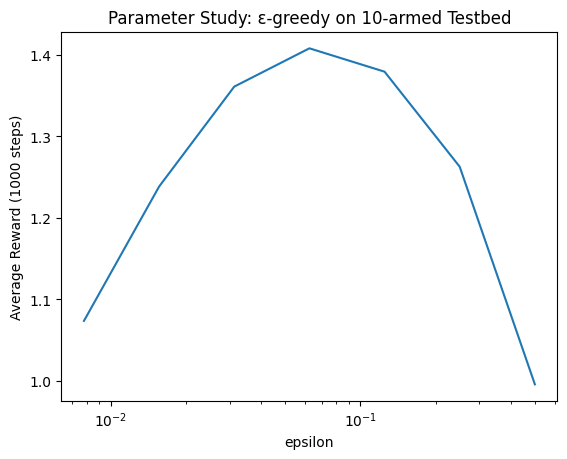

In [19]:
# Parameter Study
from tqdm import tqdm
means = np.random.normal(0, 1, 10)
# use a float base so negative exponents produce valid float values (avoids ValueError)
avg_greedy_list = []
epsilon_list = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2]
for epsilon in tqdm(epsilon_list):
    avg_greedy, opt_greedy = run_epsilon_greedy_torch_batch(means, epsilon=epsilon, runs=2000, steps=1000, batch=200, seed=42, device='cuda')
    avg_greedy_list.append(avg_greedy.mean())


plt.plot(epsilon_list, avg_greedy_list)
plt.xscale('log')
plt.xlabel('epsilon')
plt.ylabel('Average Reward (1000 steps)')
plt.title('Parameter Study: ε-greedy on 10-armed Testbed')

100%|██████████| 12/12 [00:23<00:00,  1.99s/it]


Text(0.5, 1.0, 'Parameter Study: optimistic initialization on 10-armed Testbed')

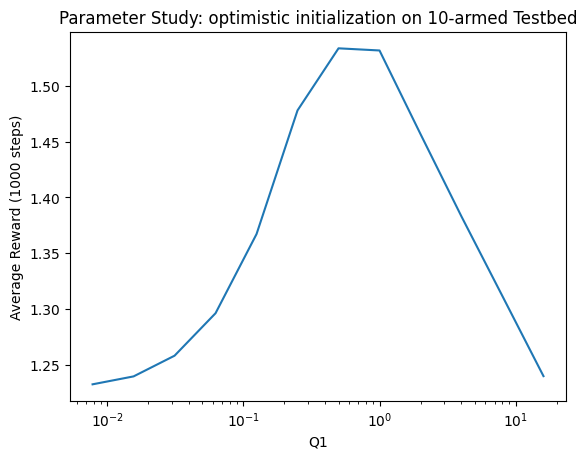

In [20]:
avg_optimistic_list = []
Q1_list = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4, 8, 16]
for Q1 in tqdm(Q1_list):
    avg_optimistic, opt_optimistic = run_optimistic_initialization_torch_batch(means, Q1=Q1, alpha=0.1, runs=2000, steps=1000, batch=200, seed=42, device='cuda')
    avg_optimistic_list.append(avg_optimistic.mean())


plt.plot(Q1_list, avg_optimistic_list)
plt.xscale('log')
plt.xlabel('Q1')
plt.ylabel('Average Reward (1000 steps)')
plt.title('Parameter Study: optimistic initialization on 10-armed Testbed')

100%|██████████| 10/10 [00:34<00:00,  3.44s/it]


Text(0.5, 1.0, 'Parameter Study: UCB on 10-armed Testbed')

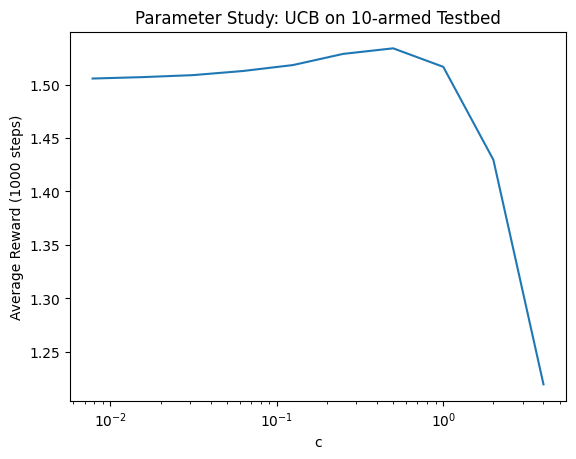

In [18]:
avg_ucb_list = []
c_list = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4]
for c in tqdm(c_list):
    avg_ucb, opt_ucb = run_ucb_torch_batch(means, c=c, runs=2000, steps=1000, batch=200, seed=42, device='cuda')
    avg_ucb_list.append(avg_ucb.mean())

plt.plot(c_list, avg_ucb_list)
plt.xscale('log')
plt.xlabel('c')
plt.ylabel('Average Reward (1000 steps)')
plt.title('Parameter Study: UCB on 10-armed Testbed')

100%|██████████| 10/10 [00:27<00:00,  2.71s/it]


Text(0.5, 1.0, 'Parameter Study: Gradient Bandit on 10-armed Testbed')

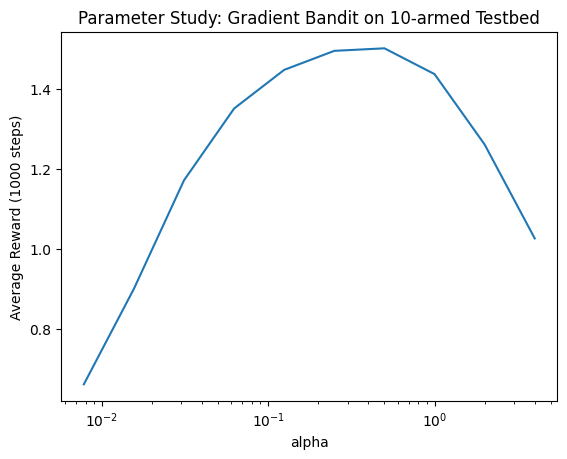

In [17]:
avg_gradient_list = []
alpha_list = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4]
for alpha in tqdm(alpha_list):
    avg_gradient, opt_gradient = run_gradient_bandit_torch_batch(means, alpha=alpha, baseline=True, runs=2000, steps=1000, batch=200, seed=42, device='cuda')
    avg_gradient_list.append(avg_gradient.mean())  

plt.plot(alpha_list, avg_gradient_list)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Average Reward (1000 steps)')
plt.title('Parameter Study: Gradient Bandit on 10-armed Testbed')


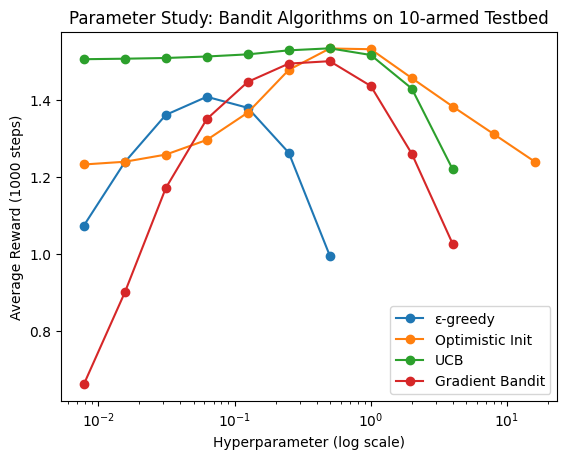

In [22]:
plt.plot(epsilon_list, avg_greedy_list, label='ε-greedy', marker='o')
plt.plot(Q1_list, avg_optimistic_list, label='Optimistic Init', marker='o')
plt.plot(c_list, avg_ucb_list, label='UCB', marker='o')
plt.plot(alpha_list, avg_gradient_list, label='Gradient Bandit', marker='o')
plt.xscale('log')
plt.xlabel('Hyperparameter (log scale)')
plt.ylabel('Average Reward (1000 steps)')
plt.title('Parameter Study: Bandit Algorithms on 10-armed Testbed')
plt.legend()

参数敏感性研究（即英文里的 “parameter study”）在算法研究与工程化实验中具有核心地位；它不仅是为找到某个“最优”参数，更重要的是系统揭示算法对超参数的依赖关系、鲁棒性范围以及可能的相变行为。开展参数分析时，应把被研究的量化目标（例如长期平均回报、收敛速度或结果方差）明确定义，并固定除目标参数之外的其他条件，包括随机种子（seed）、设备（device，如 CPU/GPU）与评估协议，只有这样才能把参数变化引起的性能差异归因于参数本身而不是外部噪声。为了获得可靠结论，单次运行往往不够，必须通过多次独立重复试验收集样本分布，用均值与置信区间或箱线图等统计量报告结果，这样才能同时把平均性能与不确定性呈现出来；如果只看均值而忽略方差，往往会误判在实际部署中不稳定但均值稍优的设置。可视化在参数分析中发挥重要的解释性作用：单参数的曲线图、带阴影的置信区间、以及多参数时的热力图或等高线能够直观地展示哪些参数区域是稳健的，哪些会导致性能突变；此外，分析收敛轨迹与极端值行为有助于发现数值不稳定或学习率过大的迹象。资源与效率约束也须并列考虑：穷尽式的网格搜索在高维超参数空间代价巨大，因此常用粗到细的分阶段扫描、随机搜索或样本高效的贝叶斯优化策略来缩小候选区域；当使用框架（例如 PyTorch）并行化或批处理（batch）大量 runs 时，应权衡内存占用和 I/O 开销，并确保并行实现不会在独立试验之间错误共享可变状态。最终，优质的参数分析应当把经验观察转化为可操作的建议：说明在哪些参数范围内算法能稳定工作、在哪些条件下需要谨慎调小学习率或引入 baseline、以及在非平稳环境中应优先采用固定步长或衰减机制，从而把孤立的调参结果升华为可复用的实验知识，而不是单纯的“调参技巧”。